In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Fonctions

In [ ]:
# Paramètres
f = 0.005 # 5mm
lambda_0 = 600e-9 # 600nm
nt = 1.0
k0 = (2 * np.pi)/(lambda_0)
kt = (2 * np.pi * nt) / lambda_0
R_pupille = 0.004 # 4mm
NA = R_pupille/f

# Grilles
N = 250
x = np.linspace(-R_pupille, R_pupille, N)
y = np.linspace(-R_pupille, R_pupille, N)
z = np.linspace(-1000e-6, 1000e-6, 4 * N)
z_micro = z * 1e6
X, Y = np.meshgrid(x, y)
Rp = np.sqrt(X**2 + Y**2)

# Fonctions
def compute_E(E_t, theta, z):
  # Calcule le champs après l'objectif du microscope
  A = -(1j * f)/(lambda_0 * kt**2)
  cos_theta = np.cos(theta)
  kz = kt * cos_theta

  E_apres = np.zeros((N, N, len(z)), dtype = complex)

  for i in range(len(z)):
    exp = f_exp(kz, z[i])

    E_3D = (E_t * exp) / cos_theta
    E_apres[:, :, i] = np.fft.fftshift(np.fft.fft2(E_3D))

  return A * E_apres

def theta_field(X, Y, R, NA):
  # Construit la grille des theta
  r = np.sqrt(X**2 + Y**2)
  a = (r/R) * (NA/nt)
  a = np.clip(a, 0, 1)
  return np.arcsin(a)

def f_exp(kz, z):
  return np.exp(1j * kz * z)

def Plot_output(field_phase): #Plot les graph apres etre passé dans l'objectif de microscope (plot les 3 coupes transversales)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    mid = [s//2 for s in field_phase.shape]
    plt.suptitle('Coupes transversales')

    x_min, x_max = -R_pupille*1e3, R_pupille*1e3
    z_min, z_max = -100, 100

    axes[0].imshow(field_phase[mid[0], :, :], cmap='viridis', aspect='auto', extent=[z_min, z_max, x_max, x_min])
    axes[0].set_xlabel('z (µm)')
    axes[0].set_ylabel('y (mm)')
    axes[0].set_title('Coupe YZ')

    axes[1].imshow(field_phase[:, mid[1], :], cmap='viridis', aspect='auto', extent=[z_min, z_max, x_max, x_min])
    axes[1].set_xlabel('z (µm)')
    axes[1].set_ylabel('x (mm)')
    axes[1].set_title('Coupe XZ')

    axes[2].imshow(field_phase[:, :, mid[2]], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[2].set_xlabel('x (mm)')
    axes[2].set_ylabel('y (mm)')
    axes[2].set_title('Coupe XY')

    plt.tight_layout()
    plt.show()


def Plot_input(E_t): # Plot l'amplitude et la phase de l'image dans la pupille d'entré
    Et_ampl = np.abs(E_t)
    Et_arg = np.angle(E_t)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plt.suptitle('Champ en entrée')

    x_min, x_max = -R_pupille*1e3, R_pupille*1e3

    axes[0].imshow(Et_ampl, cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[0].set_xlabel('x (mm)')
    axes[0].set_ylabel('y (mm)')
    axes[0].set_title('Amplitude du champ')

    axes[1].imshow(Et_arg, cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[1].set_xlabel('x (mm)')
    axes[1].set_ylabel('y (mm)')
    axes[1].set_title('Phase du champ')

    plt.tight_layout()
    plt.show()

theta = theta_field(X, Y, R_pupille, NA) # Grille des theta

def Plotfaisceau(E_apres):
  # Récupère les indices du tableau 3D des bords du faisceau
  field = np.abs(E_apres)
  mid = [s//2 for s in field.shape]
  upper_yz = np.zeros(len(z))
  lower_yz = np.zeros(len(z))

  for i in range(len(z)): # Dans le plan yz
    idx_max = N
    idx_min = 0
    seuil = (1/2) * np.max(field[mid[0], :, i]) # Seuil par rapport au pixel d'intensité max de la colonne

    for j in range(len(y)): # Recherche du pixel de la partie supérieur du faisceau
      if (field[mid[0], len(y) - j - 1, i] > seuil):
        idx_max = len(y) - j - 1
        break

    for j in range(len(y)): # Recherche du pixel de la partie inferieur du faisceau
      if (field[mid[0], j, i] > seuil):
        idx_min = j
        break

    upper_yz[i] = idx_max
    lower_yz[i] = idx_min

  return upper_yz, lower_yz # Ne renvoie que pour l'un des plan car symétrie par rotation autour de l'axe z

# Faisceau Gaussien avec ou sans phase quadratique (défocalisation)

[1.00000000e+05 1.63789371e+05 2.68269580e+05 4.39397056e+05
 7.19685673e+05 1.17876863e+06 1.93069773e+06 3.16227766e+06
 5.17947468e+06 8.48342898e+06 1.38949549e+07 2.27584593e+07
 3.72759372e+07 6.10540230e+07 1.00000000e+08]


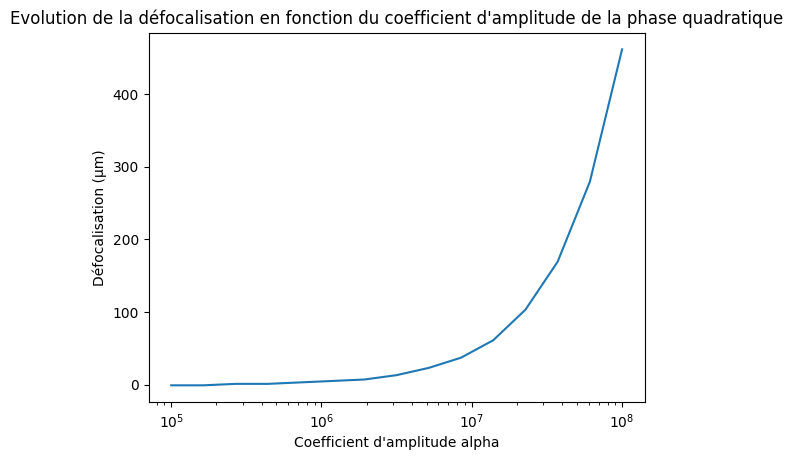

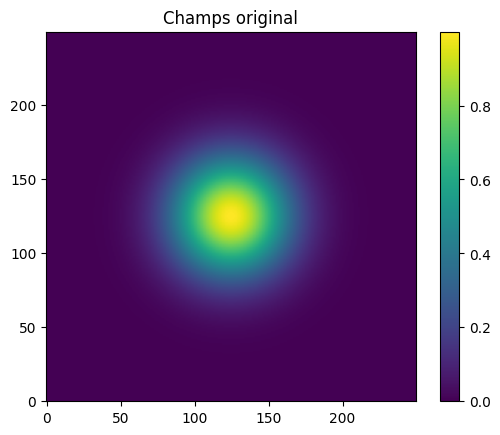

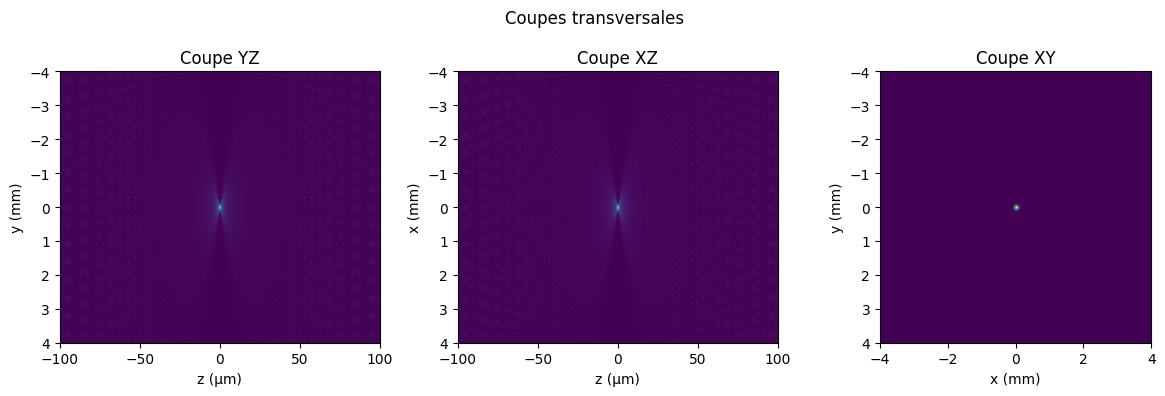

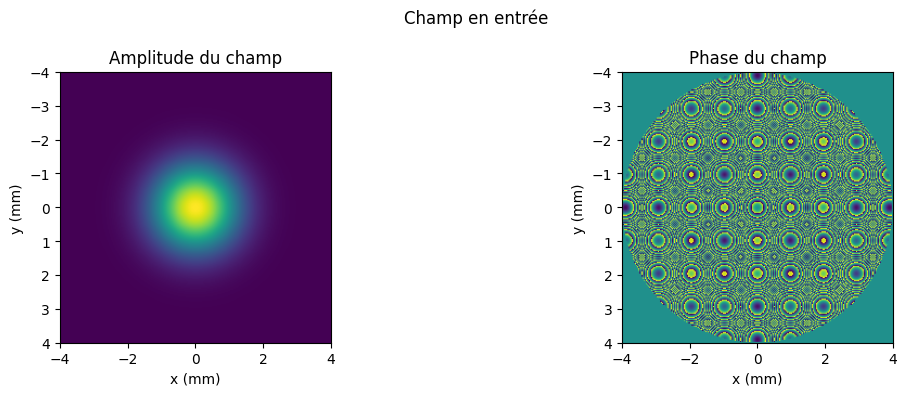

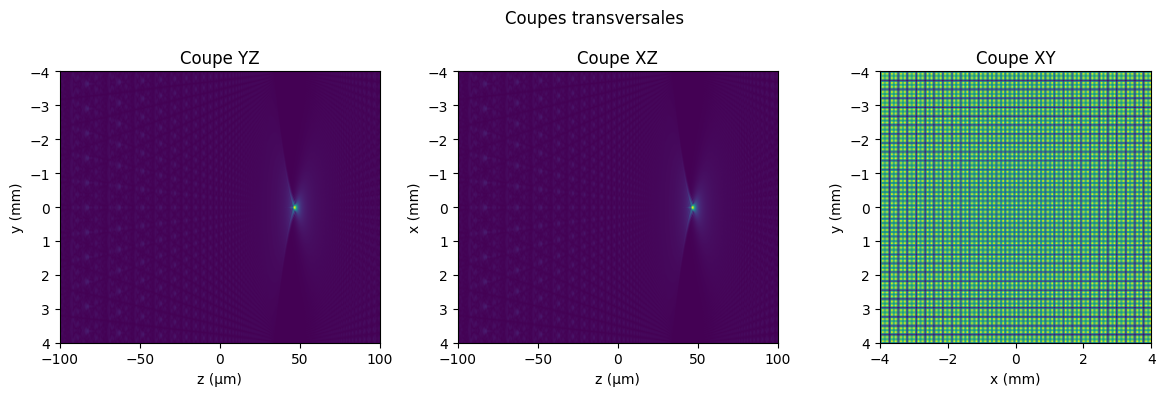

In [ ]:
# En ajoutant une phase quadratique, on observe une defocalisation du faisceau, 1e7
alpha_list = np.logspace(np.log10(1e5), np.log10(1e8), 15)
print(alpha_list)
beta = 10

pixel_size = (lambda_0 * f) / (2 * R_pupille)

defoc_list = []
for alpha in alpha_list:
  exp_phase = np.exp(1j * alpha * (X**2 + Y**2))
  Et_gausse_phase = np.exp(-beta * (Rp/R_pupille)**2) * exp_phase
  Et_gausse_phase[Rp > R_pupille] = 0 # Champs restreint à la pupille
  E_gausse_phase = compute_E(Et_gausse_phase, theta, z) # Champs après le système optique avec phase quadratique

  G_upper_yz, G_lower_yz = Plotfaisceau(E_gausse_phase)
  demi_hauteur_G = (G_upper_yz - G_lower_yz) * pixel_size * 1e6
  idx = np.argmin(demi_hauteur_G)
  defoc_list.append(z_micro[idx])


Et_gausse = np.exp(-beta * (Rp/R_pupille)**2) # Champs gaussien avant la pupille
Et_gausse[Rp > R_pupille] = 0 # Champs restreint à la pupille
E_gausse = compute_E(Et_gausse, theta, z) # Champs après le système optique

G_upper_yz, G_lower_yz = Plotfaisceau(E_gausse)
demi_hauteur_G = (G_upper_yz - G_lower_yz) * pixel_size * 1e6
idx = np.argmin(demi_hauteur_G)
defoc = z_micro[idx]


plt.figure()
plt.plot(alpha_list, defoc_list)
plt.xlabel("Coefficient d'amplitude alpha")
plt.ylabel('Défocalisation (μm)')
plt.title("Evolution de la défocalisation en fonction du coefficient d'amplitude de la phase quadratique")
plt.xscale('log')
plt.show()

# Plot du champs original sans phase quadratique
plt.figure()
plt.imshow(np.abs(Et_gausse), cmap='viridis', origin='lower')
plt.title('Champs original')
plt.colorbar()

# Plot du champs après sans phase quadratique
Plot_output(np.abs(E_gausse))

# Plot du champs original avec phase quadratique
Plot_input(Et_gausse_phase)

# Plot du champs après avec phase quadratique
Plot_output(np.abs(E_gausse_phase))

# Descente de gradient

In [ ]:
# a*(alpha)**b + c
def model(a, b, c,alpha):
  return a * (alpha)**b + c

def dfda(a, b, c,alpha):
  return (alpha)**b

def dfdb(a, b, c, alpha):
  a2 = max(1e-9, a)
  return a2 * (alpha)**b * np.log(alpha)

def dfdc(a, b, c, alpha):
  return 1

# x: liste des alpha
# y: liste des valeurs de défocalisation
def desc_grad(x, y, n_iters, lr):
  x = x/1e5 # pour éviter que la loss explose
  a = 0.01
  b = 1.0
  c = 0
  for n in range(n_iters):
    loss = 0
    dLda = 0
    dLdb = 0
    dLdc = 0

    for k in range(len(x)):
      loss += (1/2)*(y[k] - model(a, b, c, x[k]))**2
      dLda += -(y[k] - model(a, b, c, x[k])) * dfda(a, b, c, x[k])
      dLdb += -(y[k] - model(a, b, c, x[k])) * dfdb(a, b, c, x[k])
      dLdc += -(y[k] - model(a, b, c, x[k])) * dfdc(a, b, c, x[k])

    a -= lr * (dLda/len(x))
    b -= lr * (dLdb/len(x))
    c -= lr * (dLdc/len(x))
    a = max(1e-9, a)
    b = max(1e-5, b)

    if (n%5000 == 0):
      print(f"Iteration {n}: Loss={loss/len(x):.4f}, a={a:.4e}, b={b:.4e}, c={c:.4e}")
  return a, b, c

Iteration 0: Loss=10719.9767, a=1.4773e-02, b=1.0003e+00, c=7.5767e-06
Iteration 5000: Loss=8.2799, a=2.7499e-01, b=1.0770e+00, c=1.4734e-03
Iteration 10000: Loss=3.5020, a=3.1804e-01, b=1.0552e+00, c=2.1484e-03
Iteration 15000: Loss=1.7525, a=3.4475e-01, b=1.0431e+00, c=2.5256e-03
Iteration 20000: Loss=1.0063, a=3.6241e-01, b=1.0356e+00, c=2.7247e-03
Iteration 25000: Loss=0.6601, a=3.7452e-01, b=1.0307e+00, c=2.8086e-03
Iteration 30000: Loss=0.4910, a=3.8303e-01, b=1.0273e+00, c=2.8147e-03
Iteration 35000: Loss=0.4056, a=3.8909e-01, b=1.0250e+00, c=2.7668e-03
Iteration 40000: Loss=0.3615, a=3.9345e-01, b=1.0233e+00, c=2.6807e-03
Iteration 45000: Loss=0.3383, a=3.9662e-01, b=1.0221e+00, c=2.5673e-03
Iteration 50000: Loss=0.3260, a=3.9893e-01, b=1.0212e+00, c=2.4341e-03
Iteration 55000: Loss=0.3194, a=4.0062e-01, b=1.0206e+00, c=2.2866e-03
Iteration 60000: Loss=0.3158, a=4.0186e-01, b=1.0201e+00, c=2.1287e-03
Iteration 65000: Loss=0.3138, a=4.0277e-01, b=1.0198e+00, c=1.9631e-03
Iterati

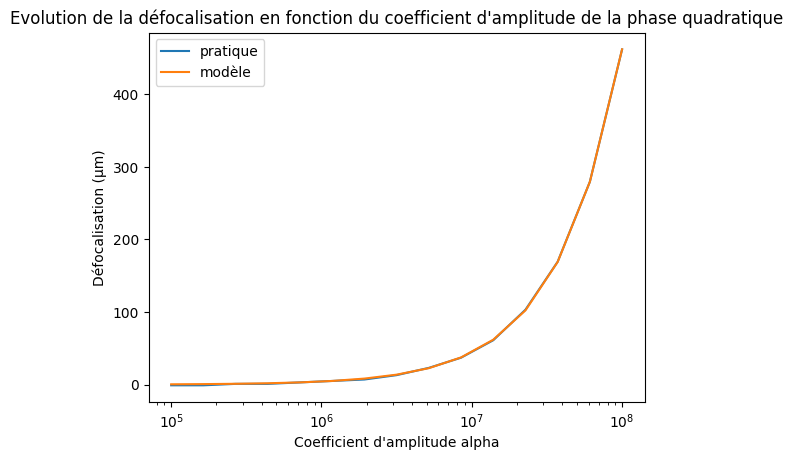

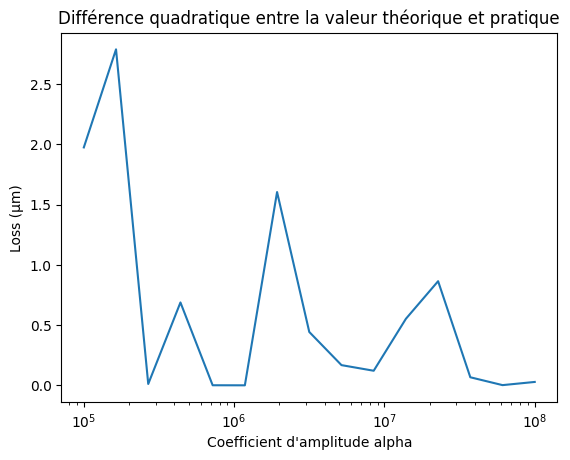

Paramètres finaux: a=3.2643121947180915e-06, b=1.0188127977759747, c=-0.001149987320910406
Loss max: 2.7889069031967337


In [ ]:
x = alpha_list
y = defoc_list
lr = 1e-7
n_iters = 150000
a, b, c = desc_grad(x, y, n_iters, lr)
a = a / (1e5**b) # car /1e5 dans la fonction et donc pendant l'entrainement
plt.figure()
plt.plot(alpha_list, defoc_list)
plt.plot(alpha_list, model(a, b, c, alpha_list))
plt.xlabel("Coefficient d'amplitude alpha")
plt.ylabel('Défocalisation (μm)')
plt.legend(["pratique", "modèle"])
plt.title("Evolution de la défocalisation en fonction du coefficient d'amplitude de la phase quadratique")
plt.xscale('log')
plt.show()

plt.figure()
plt.plot(alpha_list, (model(a, b, c, alpha_list) - defoc_list)**2)
plt.xlabel("Coefficient d'amplitude alpha")
plt.ylabel('Loss (μm)')
plt.title("Différence quadratique entre la valeur théorique et pratique")
plt.xscale('log')
plt.show()

print(f"Paramètres finaux: a={a}, b={b}, c={c}")
print(f"Loss max: {np.max((model(a, b, c, alpha_list) - defoc_list)**2)}")